In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import re
import os

In [2]:
# Data
data_path = os.path.join("..", "data", "IPL Auction (2013-2026).xlsx")
data = pd.read_excel(data_path)

data.head()

,Team,Player,Role,Value,Year
0,Chennai Super Kings,Christopher Morris,All-Rounder,625000,2013
1,Chennai Super Kings,Dirk Nannes,Bowler,600000,2013
2,Chennai Super Kings,Ben Laughlin,Bowler,20000,2013
3,Chennai Super Kings,Akila Dananjaya,All-Rounder,20000,2013
4,Chennai Super Kings,Jason Holder,Bowler,20000,2013


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1381 entries, 0 to 1380
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Team    1381 non-null   str  
 1   Player  1381 non-null   str  
 2   Role    1122 non-null   str  
 3   Value   1381 non-null   int64
 4   Year    1381 non-null   int64
dtypes: int64(2), str(3)
memory usage: 54.1 KB


In [4]:
data["Value"] = data["Value"].apply(lambda x: float(re.sub(r"[?,/]", "", x)) if isinstance(x, str) else float(x))

In [32]:
df = data.copy()

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1381 entries, 0 to 1380
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Team    1381 non-null   str    
 1   Player  1381 non-null   str    
 2   Role    1122 non-null   str    
 3   Value   1381 non-null   float64
 4   Year    1381 non-null   int64  
dtypes: float64(1), int64(1), str(3)
memory usage: 54.1 KB


In [29]:
years = sorted(df["Year"].unique())

for y in years:
    sub_df = df[df["Year"] == y].copy()

    # Min
    min_idx = sub_df["Value"].idxmin()
    min_auction = sub_df.loc[min_idx, "Value"]
    min_player = sub_df.loc[min_idx, "Player"]
    min_player_role = sub_df.loc[min_idx, "Role"]
    min_player_team = sub_df.loc[min_idx, "Team"]

    # Max
    max_idx = sub_df["Value"].idxmax()
    max_auction = sub_df.loc[max_idx, "Value"]
    max_player = sub_df.loc[max_idx, "Player"]
    max_player_role = sub_df.loc[max_idx, "Role"]
    max_player_team = sub_df.loc[max_idx, "Team"]

    # Median (pick closest value to median)
    median_auction = sub_df["Value"].median()
    median_idx = (sub_df["Value"] - median_auction).abs().idxmin()
    median_player = sub_df.loc[median_idx, "Player"]
    median_player_role = sub_df.loc[median_idx, "Role"]
    median_player_team = sub_df.loc[median_idx, "Team"]

    print(f"Year - {y}")
    print(f"Min. Auction    -> {min_player}, {min_player_role}, {min_player_team} -> INR {min_auction:.0f}")
    print(f"Max. Auction    -> {max_player}, {max_player_role}, {max_player_team} -> INR {max_auction:.0f}")
    print(f"Median (closest)-> {median_player}, {median_player_role}, {median_player_team} -> INR {median_auction:.0f}")
    print("--" * 10)

Year - 2013
Min. Auction    -> Ben Laughlin, Bowler, Chennai Super Kings -> INR 20000
Max. Auction    -> Glenn Maxwell, All-Rounder, Mumbai Indians -> INR 1000000
Median (closest)-> Luke Pomersbach, Batsman, Kings XI Punjab -> INR 300000
--------------------
Year - 2014
Min. Auction    -> Vijay Shankar, All-Rounder, Chennai Super Kings -> INR 1000000
Max. Auction    -> Yuvraj Singh, All-Rounder, Royal Challengers Bengaluru -> INR 140000000
Median (closest)-> Ben Hilfenhaus, Bowler, Chennai Super Kings -> INR 10000000
--------------------
Year - 2015
Min. Auction    -> Pratyush Singh, All-Rounder, Chennai Super Kings -> INR 1000000
Max. Auction    -> Yuvraj Singh, Batsman, Delhi Daredevils -> INR 160000000
Median (closest)-> Rahul Sharma, Bowler, Chennai Super Kings -> INR 3000000
--------------------
Year - 2016
Min. Auction    -> Chama Milind, Bowler, Delhi Daredevils -> INR 1000000
Max. Auction    -> Shane Watson, All-Rounder, Royal Challengers Bengaluru -> INR 95000000
Median (close

In [33]:
df["Value Cr"] = df["Value"] / 10000000

In [36]:

df_group = df.groupby(by=["Year"], as_index=False).agg(
    median_val = ("Value Cr", "median"),
    mean_val = ("Value Cr", "mean"),
    min_val = ("Value Cr", "min"),
    max_val = ("Value Cr", "max"),
    total_val = ("Value Cr", "sum"),
    n_players = ("Value Cr", "size")
)

df_group["per_player_val"] = df_group["total_val"]/df_group["n_players"]

df_group

,Year,median_val,mean_val,min_val,max_val,total_val,n_players,per_player_val
0,2013,0.03,0.032122,0.002,0.10,1.1885,37,0.032122
1,2014,1.00,1.705195,0.100,14.00,262.6000,154,1.705195
2,2015,0.30,1.307463,0.100,16.00,87.6000,67,1.307463
3,2016,0.50,1.446809,0.100,9.50,136.0000,94,1.446809
4,2017,0.40,1.381061,0.100,14.50,91.1500,66,1.381061
5,2018,1.70,2.554438,0.200,12.50,431.7000,169,2.554438
6,2019,0.75,1.780000,0.200,8.40,106.8000,60,1.780000
7,2020,0.90,2.262903,0.200,15.50,140.3000,62,2.262903
8,2021,0.50,2.549123,0.200,16.25,145.3000,57,2.549123
9,2022,1.05,2.704412,0.200,15.25,551.7000,204,2.704412


In [37]:
df_group["length"] = df_group["n_players"]//10

In [ ]:
df_group["median_scaled"] = df_group["median_val"]*100          # Value in INR Cr * 100 

df_group

,Year,median_val,mean_val,min_val,max_val,total_val,n_players,per_player_val,length,median_scaled
0,2013,0.03,0.032122,0.002,0.10,1.1885,37,0.032122,3,3.0
1,2014,1.00,1.705195,0.100,14.00,262.6000,154,1.705195,15,100.0
2,2015,0.30,1.307463,0.100,16.00,87.6000,67,1.307463,6,30.0
3,2016,0.50,1.446809,0.100,9.50,136.0000,94,1.446809,9,50.0
4,2017,0.40,1.381061,0.100,14.50,91.1500,66,1.381061,6,40.0
5,2018,1.70,2.554438,0.200,12.50,431.7000,169,2.554438,16,170.0
6,2019,0.75,1.780000,0.200,8.40,106.8000,60,1.780000,6,75.0
7,2020,0.90,2.262903,0.200,15.50,140.3000,62,2.262903,6,90.0
8,2021,0.50,2.549123,0.200,16.25,145.3000,57,2.549123,5,50.0
9,2022,1.05,2.704412,0.200,15.25,551.7000,204,2.704412,20,105.0


In [43]:

df["value_cr_scaled"] = df["Value Cr"]*100
df.head()

,Team,Player,Role,Value,Year,Value Cr,value_cr_scaled
0,Chennai Super Kings,Christopher Morris,All-Rounder,625000.0,2013,0.0625,6.25
1,Chennai Super Kings,Dirk Nannes,Bowler,600000.0,2013,0.0600,6.00
2,Chennai Super Kings,Ben Laughlin,Bowler,20000.0,2013,0.0020,0.20
3,Chennai Super Kings,Akila Dananjaya,All-Rounder,20000.0,2013,0.0020,0.20
4,Chennai Super Kings,Jason Holder,Bowler,20000.0,2013,0.0020,0.20


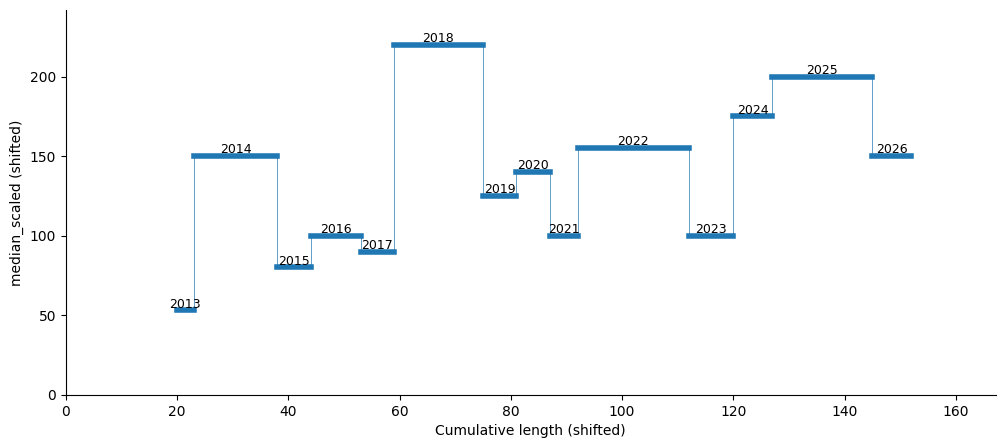

In [61]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# tweak knobs
line_thickness = 4
y_offset = 50      # shifts everything UP/DOWN (add to every y)
x_offset = 20      # shifts everything RIGHT/LEFT (add to every x)

fig, ax = plt.subplots(figsize=(12, 5))

x_cursor = 0
prev_end_x = None
prev_y = None

for _, r in df_group.sort_values("Year").iterrows():
    year = r["Year"]

    # apply y shift
    y = r["median_scaled"] + y_offset

    seg_len = r["length"]

    # base segment positions
    x_start_base = x_cursor
    x_end_base = x_cursor + seg_len

    # apply x shift (same offset added to both ends)
    x_start = x_start_base + x_offset
    x_end = x_end_base + x_offset

    # thick horizontal line for the year
    ax.add_line(Line2D(
        [x_start, x_end],
        [y, y],
        linewidth=line_thickness
    ))

    # optional: thin vertical connector between years
    if prev_end_x is not None:
        ax.add_line(Line2D(
            [x_start, x_start],
            [prev_y, y],
            linewidth=0.5
        ))

    # optional: year label
    ax.text((x_start + x_end) / 2, y, str(int(year)), ha="center", va="bottom", fontsize=9)

    # update "previous" using the shifted coordinates (so connectors align perfectly)
    prev_end_x = x_end
    prev_y = y

    # advance cursor in base space (so segment lengths remain unchanged)
    x_cursor = x_end_base

# axis limits must account for offsets
ax.set_xlim(0, (x_offset + x_cursor)*1.1)
ax.set_ylim(0, (df_group["median_scaled"].max() + y_offset) * 1.1)

ax.set_xlabel("Cumulative length (shifted)")
ax.set_ylabel("median_scaled (shifted)")
ax.spines[["top", "right"]].set_visible(False)

plt.show()